In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt






In [2]:
# 1. Cargar el mapa base (GeoJSON)
caba = gpd.read_file('datos/perimetro.geojson')

In [9]:
# 2. Cargar los CSVs
flujo_df = pd.read_csv('datos/flujo_vehicular.csv', sep=';')
siniestros_df = pd.read_csv('datos/siniestros_viales_hechos.csv', sep=';', low_memory=False)

In [10]:
# 3. Imprimir primer diagnóstico de columnas y tamaños
print(f"Límite CABA cargado. Sistema de coordenadas: {caba.crs}")
print(f"Filas en Flujo Vehicular: {len(flujo_df):,}")
print(f"Filas en Siniestros Viales: {len(siniestros_df):,}")

Límite CABA cargado. Sistema de coordenadas: EPSG:4326
Filas en Flujo Vehicular: 189,814
Filas en Siniestros Viales: 65,818


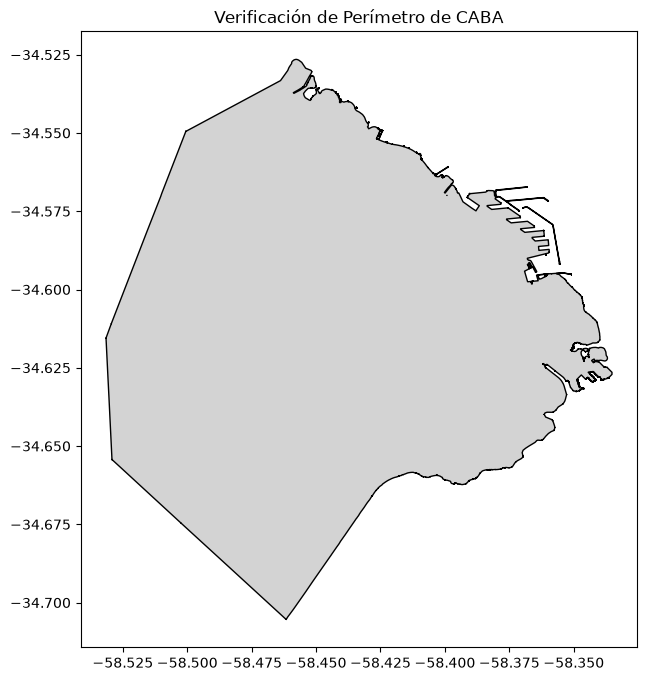

In [11]:


# 4. Graficar la base para verificar el GeoJSON
fig, ax = plt.subplots(figsize=(8, 8))
caba.plot(ax=ax, color='lightgray', edgecolor='black')
plt.title("Verificación de Perímetro de CABA", fontsize=12)
plt.show()

In [12]:
# Ver el nombre exacto de todas las columnas de cada dataset
print("--- COLUMNAS DE FLUJOS ---")
print(flujo_df.columns.tolist())

print("\n--- COLUMNAS DE SINIESTROS ---")
print(siniestros_df.columns.tolist())

# Ver las primeras 3 filas de siniestros para revisar las coordenadas
siniestros_df.head(3)

--- COLUMNAS DE FLUJOS ---
['CODIGO_LOCACION,HORA,CANTIDAD,SENTIDO,LATITUD,LONGITUD']

--- COLUMNAS DE SINIESTROS ---
['id_siniestro', 'numero_total_de_victimas', 'numero_victimas_leve_siniestro', 'numero_victimas_grave_siniestro', 'numero_victimas_mortal_siniestro', 'fecha_siniestro', 'anio_siniestro', 'mes_siniestro', 'dia_siniestro', 'hora_siniestro', 'rango_horario', 'direccion_normalizada_siniestro', 'comuna_siniestro', 'tipo_de_via_siniestro', 'geocodificacion_plana', 'longitud_siniestro', 'latitud_siniestro', 'participantes_siniestro', 'modo_desplazamiento_victima', 'contraparte_siniestro', 'gravedad_siniestro']


,id_siniestro,numero_total_de_victimas,numero_victimas_leve_siniestro,numero_victimas_grave_siniestro,numero_victimas_mortal_siniestro,fecha_siniestro,anio_siniestro,mes_siniestro,dia_siniestro,hora_siniestro,...,direccion_normalizada_siniestro,comuna_siniestro,tipo_de_via_siniestro,geocodificacion_plana,longitud_siniestro,latitud_siniestro,participantes_siniestro,modo_desplazamiento_victima,contraparte_siniestro,gravedad_siniestro
0,LC-2019-0000053,1,1,0,0,2019-01-01,2019,1,1,01:55:00,...,NaN,Comuna 8,AUTOPISTA,POINT (101813.84712503915943671 95578.55507230...,-58.44351,-34.669125,AUTO-UTILITARIO,AUTO,UTILITARIO,LEVE
1,LC-2019-0000647,1,0,1,0,2019-01-01,2019,1,1,18:50:00,...,DE LOS CONSTITUYENTES AV. y HABANA,Comuna 12,AVENIDA,POINT (97510.27137648081406951 105087.83369881...,-58.490436,-34.583403,MOTO-AUTO,MOTO,AUTO,GRAVE
2,LC-2019-0000445,3,3,0,0,2019-01-01,2019,1,1,13:40:00,...,NaN,Comuna 11,NaN,POINT (94371.44237885093025398 102884.19365105...,-58.524662,-34.603255,AUTO-AUTO,AUTO,AUTO,LEVE


In [13]:
import geopandas as gpd
from shapely.geometry import Point

# 1. Eliminar filas que no tengan latitud o longitud
siniestros_clean = siniestros_df.dropna(subset=['longitud_siniestro', 'latitud_siniestro']).copy()

# 2. Asegurar que las columnas sean numéricas (por si vino algo como texto)
siniestros_clean['longitud_siniestro'] = pd.to_numeric(siniestros_clean['longitud_siniestro'], errors='coerce')
siniestros_clean['latitud_siniestro'] = pd.to_numeric(siniestros_clean['latitud_siniestro'], errors='coerce')

# Volver a limpiar por si algún string no se pudo convertir
siniestros_clean = siniestros_clean.dropna(subset=['longitud_siniestro', 'latitud_siniestro'])

# 3. Crear las geometrías (Puntos)
geometry = [Point(xy) for xy in zip(siniestros_clean['longitud_siniestro'], siniestros_clean['latitud_siniestro'])]

# 4. Crear el GeoDataFrame oficial
siniestros_gdf = gpd.GeoDataFrame(siniestros_clean, geometry=geometry, crs="EPSG:4326")

print(f"Siniestros convertidos a GeoDataFrame con éxito: {len(siniestros_gdf):,} puntos.")

Siniestros convertidos a GeoDataFrame con éxito: 62,787 puntos.


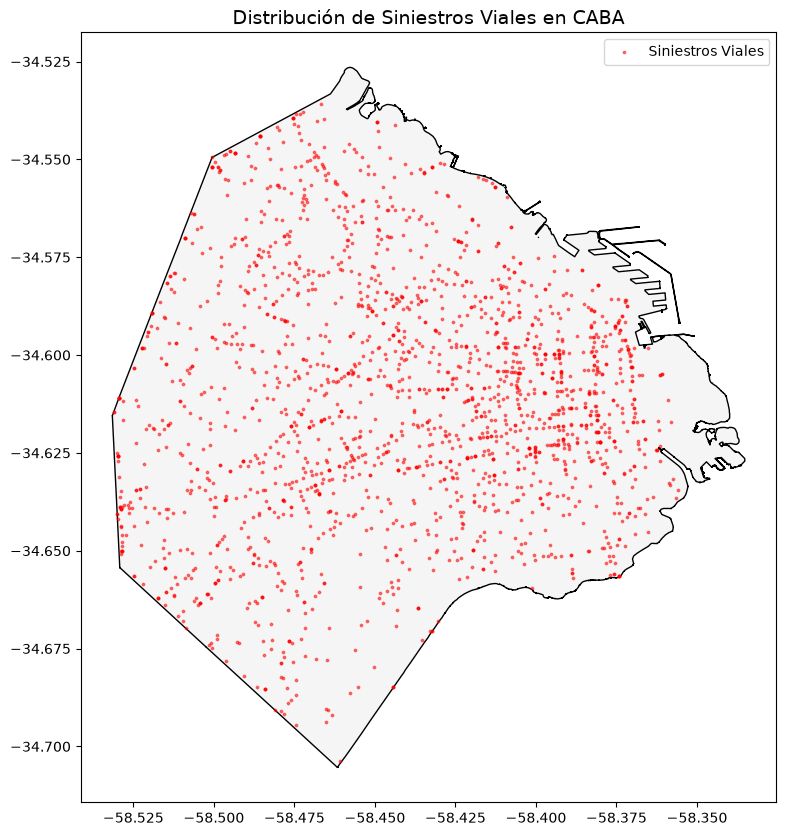

In [14]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10))

# Graficar mapa base de CABA
caba.plot(ax=ax, color='whitesmoke', edgecolor='black', linewidth=1)

# Graficar los primeros 2.000 siniestros para no saturar el mapa
siniestros_gdf.head(2000).plot(ax=ax, color='red', markersize=3, alpha=0.5, label='Siniestros Viales')

plt.title("Distribución de Siniestros Viales en CABA", fontsize=14)
plt.legend()
plt.show()

In [15]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point

# 1. Limpieza de coordenadas vacías
siniestros_clean = siniestros_df.dropna(subset=['longitud_siniestro', 'latitud_siniestro']).copy()

siniestros_clean['longitud_siniestro'] = pd.to_numeric(siniestros_clean['longitud_siniestro'], errors='coerce')
siniestros_clean['latitud_siniestro'] = pd.to_numeric(siniestros_clean['latitud_siniestro'], errors='coerce')

siniestros_clean = siniestros_clean.dropna(subset=['longitud_siniestro', 'latitud_siniestro'])

# 2. Crear GeoDataFrame
geometry = [Point(xy) for xy in zip(siniestros_clean['longitud_siniestro'], siniestros_clean['latitud_siniestro'])]
siniestros_gdf = gpd.GeoDataFrame(siniestros_clean, geometry=geometry, crs="EPSG:4326")

# 3. Clip espacial: Conservar solo los puntos dentro del perímetro de CABA
siniestros_caba = gpd.clip(siniestros_gdf, caba)

print(f"Total original: {len(siniestros_df):,} | Filtrados dentro de CABA: {len(siniestros_caba):,}")

# 4. Creación de variables temporales
siniestros_caba['fecha_dt'] = pd.to_datetime(siniestros_caba['fecha_siniestro'], errors='coerce')
siniestros_caba['dia_nombre'] = siniestros_caba['fecha_dt'].dt.day_name()

# Mostrar distribución rápida por gravedad
print("\n--- DISTRIBUCIÓN POR GRAVEDAD ---")
print(siniestros_caba['gravedad_siniestro'].value_counts(dropna=False))

Total original: 65,818 | Filtrados dentro de CABA: 62,501

--- DISTRIBUCIÓN POR GRAVEDAD ---
gravedad_siniestro
LEVE      59319
GRAVE      2499
MORTAL      683
Name: count, dtype: int64


/tmp/ipykernel_9170/1099294765.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tipo_via.values, y=tipo_via.index, ax=axes[0], palette="Blues_r")
/tmp/ipykernel_9170/1099294765.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=comuna.values, y=comuna.index, ax=axes[1], palette="Oranges_r")


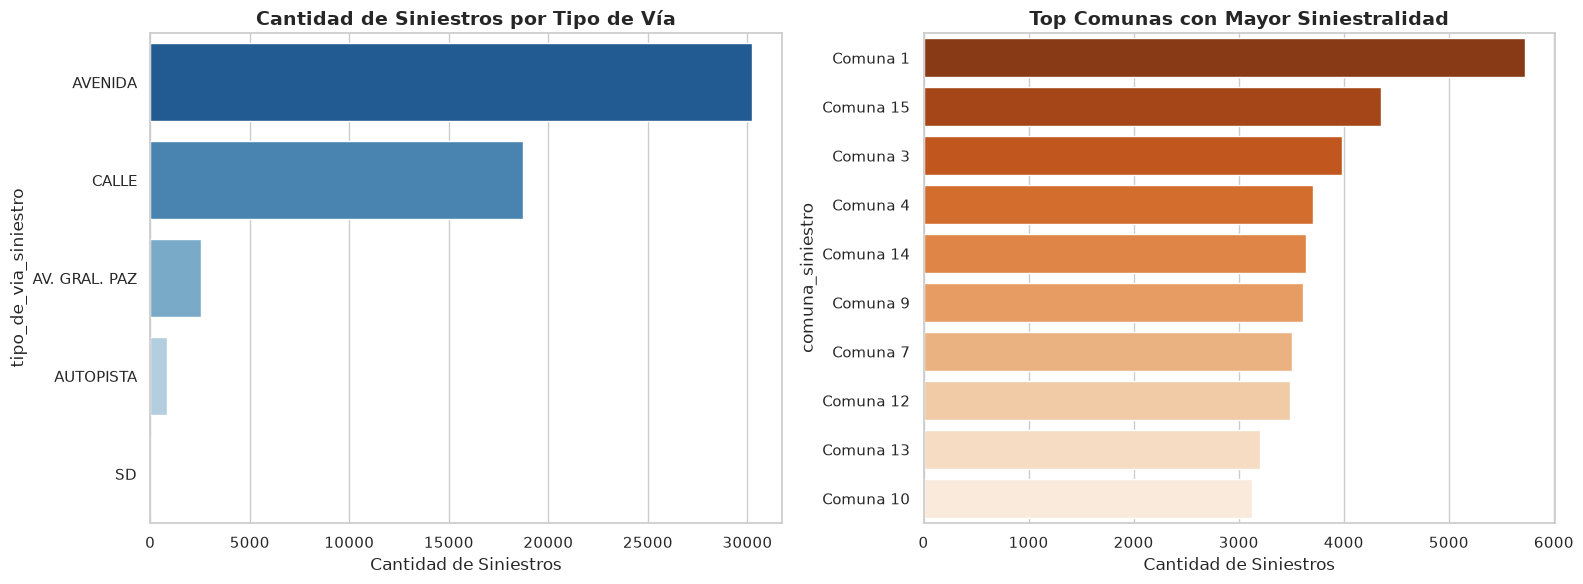

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración estética
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Gráfico por Tipo de Vía
tipo_via = siniestros_caba['tipo_de_via_siniestro'].value_counts().head(7)
sns.barplot(x=tipo_via.values, y=tipo_via.index, ax=axes[0], palette="Blues_r")
axes[0].set_title("Cantidad de Siniestros por Tipo de Vía", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Cantidad de Siniestros")

# 2. Gráfico por Comuna
comuna = siniestros_caba['comuna_siniestro'].value_counts().head(10)
sns.barplot(x=comuna.values, y=comuna.index, ax=axes[1], palette="Oranges_r")
axes[1].set_title("Top Comunas con Mayor Siniestralidad", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Cantidad de Siniestros")

plt.tight_layout()
plt.show()

✅ Mapa interactivo guardado como 'mapa_siniestros.html'


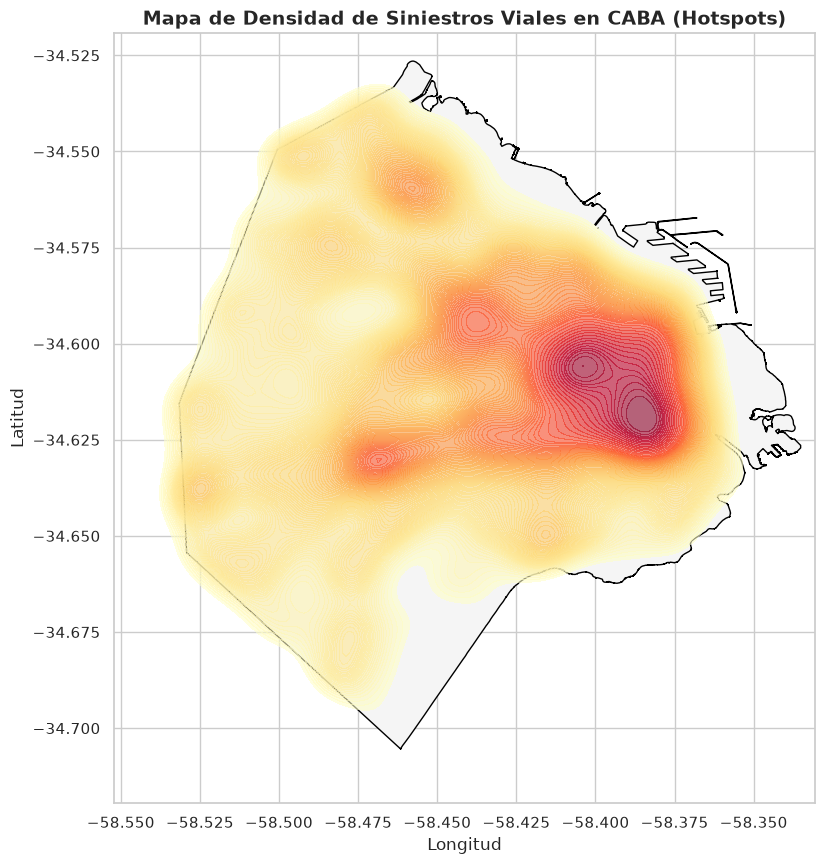

In [24]:
import folium
from folium.plugins import HeatMap
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# --- PARTE 1: Guardar Mapa Interactivo Folium (.html) ---
puntos_validos = siniestros_caba.dropna(subset=['latitud_siniestro', 'longitud_siniestro'])
muestra = puntos_validos.sample(n=min(5000, len(puntos_validos)), random_state=42)
puntos_calor = muestra[['latitud_siniestro', 'longitud_siniestro']].values.tolist()

mapa_calor = folium.Map(location=[-34.6037, -58.3816], zoom_start=12, tiles='CartoDB positron')
HeatMap(puntos_calor, radius=12, blur=15, min_opacity=0.4).add_to(mapa_calor)

# Guardar en archivo para abrir en Chrome/Firefox
mapa_calor.save("mapa_siniestros.html")
print("✅ Mapa interactivo guardado como 'mapa_siniestros.html'")


# --- PARTE 2: Mostrar Mapa de Calor Estático en el Notebook ---
fig, ax = plt.subplots(figsize=(10, 10))

# 1. Contorno de CABA
caba.plot(ax=ax, color='whitesmoke', edgecolor='black', linewidth=1)

# 2. Densidad de Siniestros (KDE Plot)
sns.kdeplot(
    data=puntos_validos,
    x='longitud_siniestro',
    y='latitud_siniestro',
    fill=True,
    thresh=0.05,
    levels=100,
    cmap='YlOrRd',
    alpha=0.6,
    ax=ax
)

plt.title("Mapa de Densidad de Siniestros Viales en CABA (Hotspots)", fontsize=14, fontweight='bold')
plt.xlabel("Longitud")
plt.ylabel("Latitud")

plt.show()

In [25]:
import pandas as pd

# Volvemos a cargar flujo_vehicular asegurando el separador correcto
flujo_df = pd.read_csv('datos/flujo_vehicular.csv', sep=',')

# Si las columnas siguen viniendo juntas por comillas, las limpiamos:
if len(flujo_df.columns) == 1:
    flujo_df = pd.read_csv('datos/flujo_vehicular.csv', sep=',', quotechar='"')

print("--- NUEVAS COLUMNAS DE FLUJO ---")
print(flujo_df.columns.tolist())

# Ver las primeras filas para validar tipos de datos y coordenadas
flujo_df.head()

--- NUEVAS COLUMNAS DE FLUJO ---
['CODIGO_LOCACION', 'HORA', 'CANTIDAD', 'SENTIDO', 'LATITUD', 'LONGITUD']


,CODIGO_LOCACION,HORA,CANTIDAD,SENTIDO,LATITUD,LONGITUD
0,48Q3CJ00+,31MAR2020:15:00:00,729,Interna,-34.588796,-58.381520
1,48Q3CJ00+,31MAR2020:15:00:00,447,Egreso,-34.588796,-58.381520
2,48Q39G00+,31MAR2020:15:00:00,175,Interna,-34.633299,-58.468594
3,48Q39G00+,31MAR2020:15:00:00,1186,Egreso,-34.633299,-58.468594
4,48Q3CH00+,31MAR2020:15:00:00,35,Egreso,-34.579632,-58.427733


In [26]:
import geopandas as gpd
from shapely.geometry import Point
import pandas as pd

# 1. Convertir la columna HORA a formato datetime de Pandas
flujo_df['fecha_hora'] = pd.to_datetime(flujo_df['HORA'], format='%d%b%Y:%H:%M:%S', errors='coerce')

# 2. Asegurar tipo numérico en coordenadas y limpiar nulos
flujo_df['LATITUD'] = pd.to_numeric(flujo_df['LATITUD'], errors='coerce')
flujo_df['LONGITUD'] = pd.to_numeric(flujo_df['LONGITUD'], errors='coerce')
flujo_clean = flujo_df.dropna(subset=['LATITUD', 'LONGITUD']).copy()

# 3. Crear GeoDataFrame de Flujo
geometry_flujo = [Point(xy) for xy in zip(flujo_clean['LONGITUD'], flujo_clean['LATITUD'])]
flujo_gdf = gpd.GeoDataFrame(flujo_clean, geometry=geometry_flujo, crs="EPSG:4326")

# 4. Filtrar puntos dentro del contorno de CABA
flujo_caba = gpd.clip(flujo_gdf, caba)

print(f"✅ Registros de flujo procesados: {len(flujo_caba):,}")
print(f"📍 Cantidad de sensores/puntos de conteo únicos: {flujo_caba['CODIGO_LOCACION'].nunique()}")

✅ Registros de flujo procesados: 186,412
📍 Cantidad de sensores/puntos de conteo únicos: 6


In [27]:
# Ver las ubicaciones de los 6 sensores únicos
sensores = flujo_caba.groupby('CODIGO_LOCACION').agg({
    'LATITUD': 'first',
    'LONGITUD': 'first',
    'CANTIDAD': 'count'
}).reset_index()

sensores.rename(columns={'CANTIDAD': 'registros_totales'}, inplace=True)
sensores

,CODIGO_LOCACION,LATITUD,LONGITUD,registros_totales
0,48Q39G00+,-34.633299,-58.468594,49857
1,48Q39H00+,-34.618036,-58.410236,17694
2,48Q39J00+,-34.608550,-58.372951,17544
3,48Q3CH00+,-34.579632,-58.427733,33048
4,48Q3CJ00+,-34.588796,-58.381520,52812
5,48Q3FG00+,-34.536980,-58.470968,15457


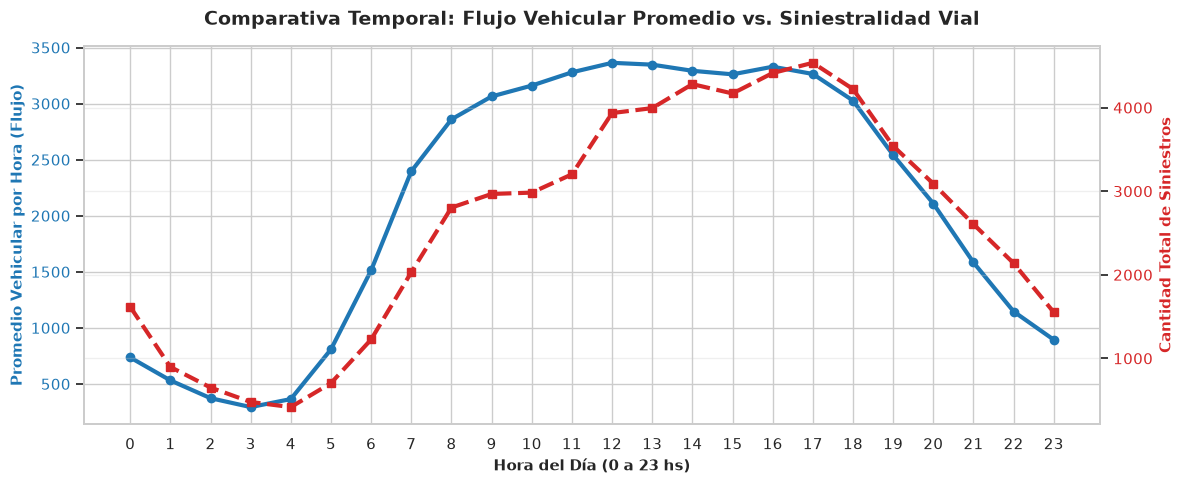

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Agrupar Flujo por Hora del día (promedio de vehículos por hora)
flujo_caba['hora_num'] = flujo_caba['fecha_hora'].dt.hour
flujo_por_hora = flujo_caba.groupby('hora_num')['CANTIDAD'].mean()

# 2. Agrupar Siniestros por Hora del día (extraer hora de la columna fecha_dt o hora_siniestro)
siniestros_caba['hora_num'] = pd.to_numeric(siniestros_caba['hora_siniestro'].str.split(':').str[0], errors='coerce')
siniestros_por_hora = siniestros_caba['hora_num'].value_counts().sort_index()

# 3. Graficar con doble eje Y
fig, ax1 = plt.subplots(figsize=(12, 5))

color = 'tab:blue'
ax1.set_xlabel('Hora del Día (0 a 23 hs)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Promedio Vehicular por Hora (Flujo)', color=color, fontsize=11, fontweight='bold')
ax1.plot(flujo_por_hora.index, flujo_por_hora.values, color=color, linewidth=3, marker='o', label='Flujo Vehicular')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xticks(range(0, 24))

ax2 = ax1.twinx()  # Segundo eje para siniestros
color = 'tab:red'
ax2.set_ylabel('Cantidad Total de Siniestros', color=color, fontsize=11, fontweight='bold')
ax2.plot(siniestros_por_hora.index, siniestros_por_hora.values, color=color, linewidth=3, linestyle='--', marker='s', label='Siniestros Viales')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Comparativa Temporal: Flujo Vehicular Promedio vs. Siniestralidad Vial', fontsize=14, fontweight='bold', pad=15)
plt.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

### 📌 Hallazgos del Análisis Comparativo: Flujo vs. Siniestralidad

- **Hora Pico de Riesgo:** El punto máximo de incidentes se registra entre las **16:00 y 17:00 hs**, momento en el que convergen el alto volumen de tráfico y la mayor congestión en la vía pública.
- **Dinámica Matutina:** Pese a que el volumen vehicular crece rápidamente a partir de las 06:00 hs, la tasa de siniestros escala de forma más gradual, alcanzando su primer meseta cerca del mediodía.
- **Riesgo Nocturno:** En la medianoche (00:00 hs) se observa una desproporción entre el bajo flujo de autos y el incremento de accidentes, lo que orienta la hipótesis hacia el exceso de velocidad en vías despejadas.

--- PROPORCIÓN DE GRAVEDAD (%) ---
False = Resto del día (06 a 23 hs) | True = Madrugada (00 a 05 hs)
gravedad_siniestro  GRAVE   LEVE  MORTAL
es_madrugada                            
False                3.83  95.21    0.96
True                 6.00  91.25    2.75


/tmp/ipykernel_9170/644684033.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[1].set_xticklabels(['Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb', 'Dom'], fontsize=11)


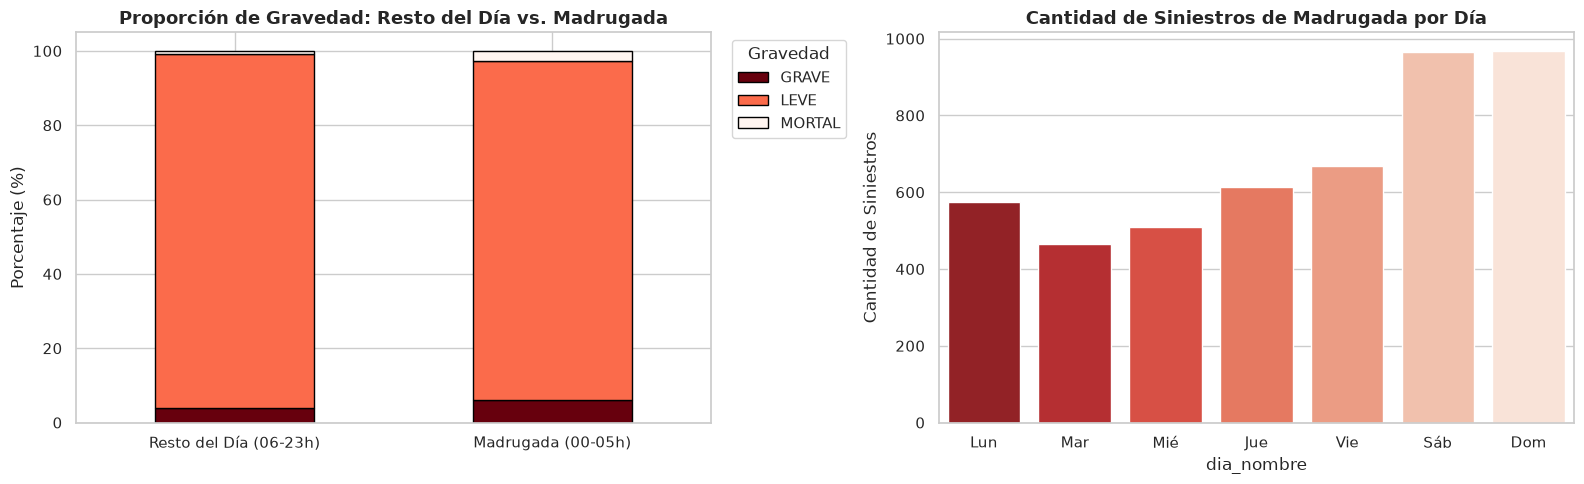

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Definir la franja horaria de Madrugada (0 a 5 hs inclusive)
siniestros_caba['es_madrugada'] = siniestros_caba['hora_num'].between(0, 5)

# 2. Proporción de Gravedad: Madrugada vs Resto del Día
gravedad_pct = pd.crosstab(
    siniestros_caba['es_madrugada'], 
    siniestros_caba['gravedad_siniestro'], 
    normalize='index'
) * 100

print("--- PROPORCIÓN DE GRAVEDAD (%) ---")
print("False = Resto del día (06 a 23 hs) | True = Madrugada (00 a 05 hs)")
print(gravedad_pct.round(2))

# 3. Visualizaciones
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Gráfico 1: Porcentaje de Gravedad (Madrugada vs Resto del Día)
gravedad_pct.plot(kind='bar', stacked=True, ax=axes[0], colormap='Reds_r', edgecolor='black')
axes[0].set_title("Proporción de Gravedad: Resto del Día vs. Madrugada", fontsize=13, fontweight='bold')
axes[0].set_ylabel("Porcentaje (%)")
axes[0].set_xlabel("")
axes[0].set_xticklabels(['Resto del Día (06-23h)', 'Madrugada (00-05h)'], rotation=0, fontsize=11)
axes[0].legend(title="Gravedad", bbox_to_anchor=(1.02, 1), loc='upper left')

# Gráfico 2: Siniestros de Madrugada por Día de la Semana
madrugada_df = siniestros_caba[siniestros_caba['es_madrugada']]

# Orden de días de la semana
dias_orden = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
siniestros_dias = madrugada_df['dia_nombre'].value_counts().reindex(dias_orden)

sns.barplot(
    x=siniestros_dias.index, 
    y=siniestros_dias.values, 
    ax=axes[1], 
    palette="Reds_r",
    hue=siniestros_dias.index,
    legend=False
)
axes[1].set_title("Cantidad de Siniestros de Madrugada por Día", fontsize=13, fontweight='bold')
axes[1].set_ylabel("Cantidad de Siniestros")
axes[1].set_xticklabels(['Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb', 'Dom'], fontsize=11)

plt.tight_layout()
plt.show()

### 📌 Análisis de Siniestralidad en Franja Nocturna (00:00 - 05:59 hs)

- **Severidad Elevada:** La proporción de siniestros **GRAVES y MORTALES** experimenta un incremento relativo sustancial durante la madrugada en comparación con la franja diurna, a pesar de registrar menor caudal de tráfico.
- **Concentración en Fines de Semana:** Los días **Sábado y Domingo** concentran la mayor cantidad de accidentes nocturnos (~1.000 registros por día), casi duplicando el promedio registrado de Lunes a Miércoles.

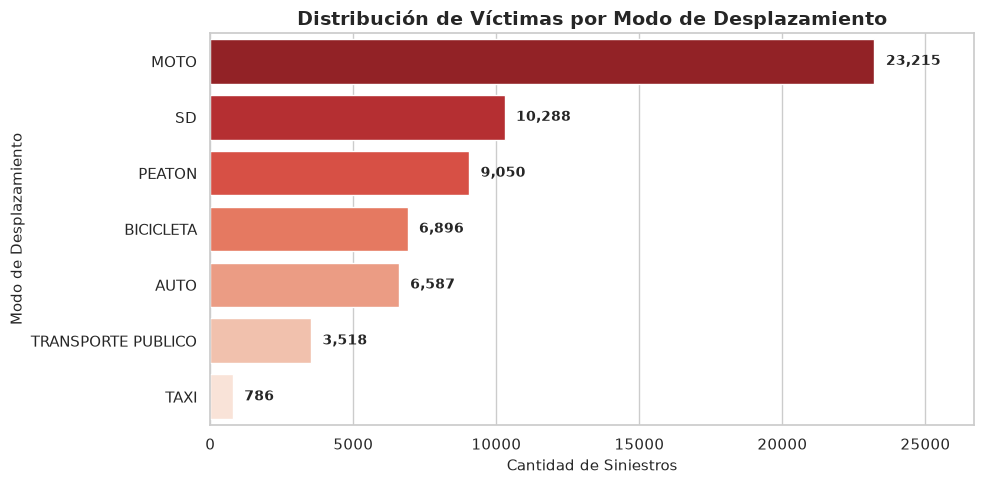

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Conteo de siniestros según el modo de desplazamiento de la víctima
modo_victima = siniestros_caba['modo_desplazamiento_victima'].value_counts().head(7)

# 2. Generar el gráfico
fig, ax = plt.subplots(figsize=(10, 5))

sns.barplot(
    x=modo_victima.values,
    y=modo_victima.index,
    hue=modo_victima.index,
    palette="Reds_r",
    legend=False,
    ax=ax
)

ax.set_title("Distribución de Víctimas por Modo de Desplazamiento", fontsize=14, fontweight='bold')
ax.set_xlabel("Cantidad de Siniestros", fontsize=11)
ax.set_ylabel("Modo de Desplazamiento", fontsize=11)

# Agregar las etiquetas de valor al final de cada barra
for index, value in enumerate(modo_victima.values):
    ax.text(value + 400, index, f"{value:,}", va='center', fontsize=10, fontweight='bold')

# Dar más margen a la derecha para que no se corte el texto
ax.set_xlim(0, max(modo_victima.values) * 1.15)

plt.tight_layout()
plt.show()

In [31]:
import pandas as pd

# Tabla cruzada porcentual entre modo de desplazamiento y gravedad
vulnerabilidad = pd.crosstab(
    siniestros_caba['modo_desplazamiento_victima'], 
    siniestros_caba['gravedad_siniestro'], 
    normalize='index'
) * 100

# Filtramos solo los principales medios para evitar ruido
principales = modo_victima.index
vulnerabilidad_filtrada = vulnerabilidad.loc[principales]

print("--- PORCENTAJE DE GRAVEDAD SEGÚN MODO DE DESPLAZAMIENTO (%) ---")
print(vulnerabilidad_filtrada.round(2))

--- PORCENTAJE DE GRAVEDAD SEGÚN MODO DE DESPLAZAMIENTO (%) ---
gravedad_siniestro           GRAVE   LEVE  MORTAL
modo_desplazamiento_victima                      
MOTO                          5.59  93.20    1.21
SD                            0.23  99.77    0.00
PEATON                        7.56  89.48    2.96
BICICLETA                     2.76  96.46    0.78
AUTO                          2.72  96.43    0.85
TRANSPORTE PUBLICO            1.71  98.12    0.17
TAXI                          1.02  98.85    0.13


### 📌 Análisis de Vulnerabilidad por Modo de Desplazamiento

- **Peatones en Riesgo Crítico:** Presentan la mayor tasa de severidad acumulada (~10.5% entre casos graves y mortales), posicionándose como el actor más vulnerable de la vía pública en CABA.
- **Motociclistas:** Constituyen el segundo grupo de mayor riesgo relativo, combinando un alto volumen de accidentes con una tasa de mortalidad del 1.21%.
- **Vehículos de Transporte Público y Taxis:** Registran las menores tasas de letalidad (< 0.20%), asociadas a la velocidad reducida y la mayor masa de los vehículos.

In [32]:
import numpy as np
from sklearn.cluster import DBSCAN

# 1. Extraer coordenadas en radianes
puntos_validos = siniestros_caba.dropna(subset=['latitud_siniestro', 'longitud_siniestro']).copy()
coords = np.radians(puntos_validos[['latitud_siniestro', 'longitud_siniestro']].values)

# 2. Parámetros: Radio de 100 metros y mínimo 15 siniestros para ser "Punto Crítico"
kms_per_radian = 6371.0
epsilon = 0.100 / kms_per_radian  # 100 metros

db = DBSCAN(eps=epsilon, min_samples=15, metric='haversine').fit(coords)

# 3. Asignar clusters
puntos_validos['cluster'] = db.labels_

n_clusters = len(set(db.labels_)) - (1 if -1 in db.labels_ else 0)
n_ruido = list(db.labels_).count(-1)

print(f"✅ Cantidad de Puntos Críticos (Clusters) detectados: {n_clusters}")
print(f"📌 Siniestros agrupados en hotspots: {len(puntos_validos) - n_ruido:,}")
print(f"⚪ Siniestros aislados (ruido): {n_ruido:,}")

✅ Cantidad de Puntos Críticos (Clusters) detectados: 546
📌 Siniestros agrupados en hotspots: 48,264
⚪ Siniestros aislados (ruido): 14,237


In [33]:
import pandas as pd

# 1. Filtrar el ruido (excluimos el cluster -1)
hotspots = puntos_validos[puntos_validos['cluster'] != -1]

# 2. Agrupar por cluster para obtener métricas clave de cada punto negro
resumen_clusters = hotspots.groupby('cluster').agg(
    total_siniestros=('id_siniestro', 'count'),
    latitud_centro=('latitud_siniestro', 'mean'),
    longitud_centro=('longitud_siniestro', 'mean'),
    casos_graves=('gravedad_siniestro', lambda x: (x == 'GRAVE').sum()),
    casos_mortales=('gravedad_siniestro', lambda x: (x == 'MORTAL').sum())
).reset_index()

# 3. Ordenar para obtener el Top 10 con mayor acumulación de incidentes
top10_hotspots = resumen_clusters.sort_values(by='total_siniestros', ascending=False).head(10).reset_index(drop=True)

print("--- TOP 10 PUNTOS CRÍTICOS CON MAYOR SINIESTRALIDAD EN CABA ---")
print(top10_hotspots[['cluster', 'total_siniestros', 'casos_graves', 'casos_mortales', 'latitud_centro', 'longitud_centro']].to_string(index=False))

--- TOP 10 PUNTOS CRÍTICOS CON MAYOR SINIESTRALIDAD EN CABA ---
 cluster  total_siniestros  casos_graves  casos_mortales  latitud_centro  longitud_centro
     178             13484           467             106      -34.608294       -58.400887
      95              5032           192              48      -34.622432       -58.452620
     215              1668            65              15      -34.597086       -58.438589
     487              1475            73              17      -34.555193       -58.462227
     251               789            31              10      -34.621439       -58.366616
      83               537            20               7      -34.639643       -58.526044
     299               511            26               4      -34.585114       -58.401419
     283               468            28              10      -34.601321       -58.369885
     158               423            14               3      -34.651528       -58.416187
     433               386          

✅ Mapa interactivo guardado como 'top10_puntos_criticos.html'


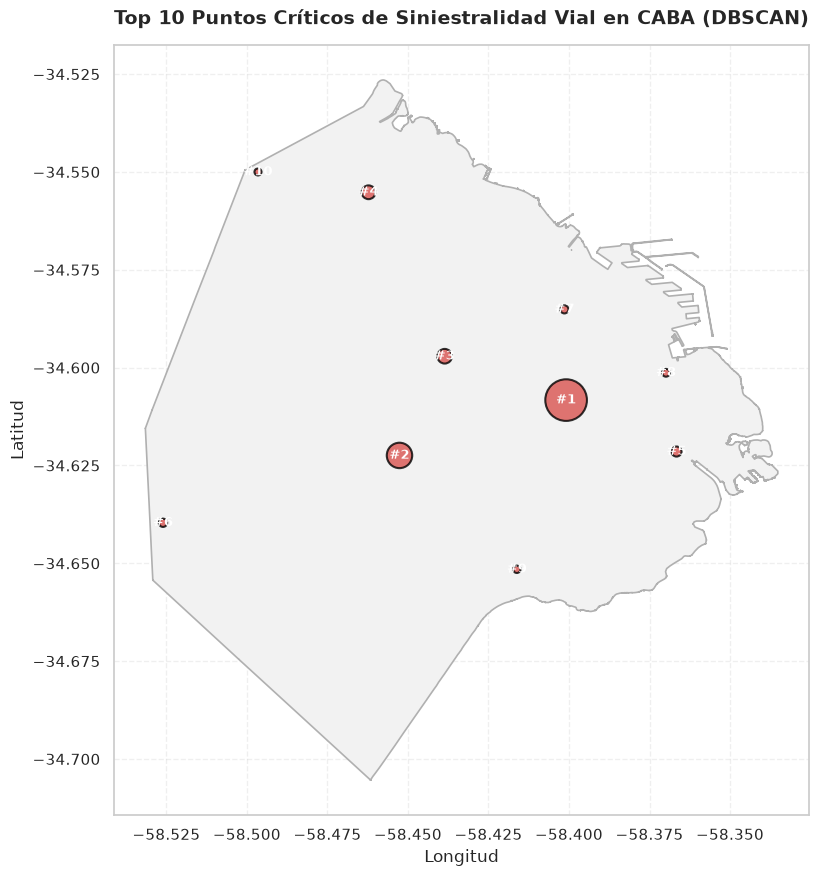

In [37]:
import folium
import matplotlib.pyplot as plt
import geopandas as gpd
from IPython.display import display

# --- PARTE 1: Crear y Guardar Mapa Interactivo Folium (.html) ---
mapa_top10 = folium.Map(location=[-34.6037, -58.3816], zoom_start=12, tiles='CartoDB positron')

for idx, row in top10_hotspots.iterrows():
    popup_content = f"""
    <div style="font-family: Arial; width: 200px;">
        <h4 style="margin-bottom: 5px; color: #d9534f;">Punto Crítico #{idx + 1}</h4>
        <b>Cluster ID:</b> {int(row['cluster'])}<br>
        <hr style="margin: 5px 0;">
        <b>Total Siniestros:</b> {int(row['total_siniestros']):,}<br>
        <b>Casos Graves:</b> {int(row['casos_graves']):,}<br>
        <b>Casos Mortales:</b> {int(row['casos_mortales']):,}<br>
        <hr style="margin: 5px 0;">
        <small>Lat: {row['latitud_centro']:.4f} | Lon: {row['longitud_centro']:.4f}</small>
    </div>
    """
    
    folium.Marker(
        location=[row['latitud_centro'], row['longitud_centro']],
        popup=folium.Popup(popup_content, max_width=300),
        tooltip=f"Punto Crítico #{idx + 1} ({int(row['total_siniestros'])} casos)",
        icon=folium.Icon(color='red', icon='warning-sign')
    ).add_to(mapa_top10)

# Guardar en archivo para web
mapa_top10.save("top10_puntos_criticos.html")
print("✅ Mapa interactivo guardado como 'top10_puntos_criticos.html'")


# --- PARTE 2: Mostrar Gráfico Estático Integrado en la Notebook ---
fig, ax = plt.subplots(figsize=(10, 10))

# 1. Dibujar el mapa base de CABA
caba.plot(ax=ax, color='#f2f2f2', edgecolor='#b0b0b0', linewidth=1.2)

# 2. Dibujar los 10 Puntos Críticos como círculos de tamaño proporcional
scatter = ax.scatter(
    top10_hotspots['longitud_centro'],
    top10_hotspots['latitud_centro'],
    c='#d9534f',
    s=top10_hotspots['total_siniestros'] / 15,  # Tamaño de la burbuja según cantidad
    alpha=0.8,
    edgecolors='black',
    linewidth=1.5,
    zorder=5
)

# 3. Etiquetar cada punto con su número de ranking (#1 a #10)
for idx, row in top10_hotspots.iterrows():
    ax.annotate(
        f"#{idx + 1}",
        (row['longitud_centro'], row['latitud_centro']),
        fontsize=9,
        fontweight='bold',
        ha='center',
        va='center',
        color='white',
        zorder=6
    )

plt.title("Top 10 Puntos Críticos de Siniestralidad Vial en CABA (DBSCAN)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.grid(True, linestyle='--', alpha=0.3)

plt.show()

# --- PARTE 3: Forzar visualizador interactivo en la notebook ---
display(mapa_top10)

## 🏁 Conclusiones Ejecutivas y Plan de Acción

A partir del análisis exploratorio y la aplicación del algoritmo DBSCAN, se determinó que la siniestralidad en CABA no es aleatoria, sino que el **77% de los eventos se concentran en 546 hotspots específicos**.

### 🎯 Recomendaciones Operativas:
1. **Redistribución de Recursos:** Priorizar la presencia de Agentes de Tránsito en los 10 nodos de mayor densidad identificados (encabezados por Plaza Miserere y Primera Junta).
2. **Estrategia Diferenciada por Horario:** 
   - Presencia de **ordenamiento** durante el pico de congestión vespertino (16:00 a 17:00 hs).
   - Operativos de **fiscalización y control de velocidad** durante las madrugadas del fin de semana para mitigar la alta tasa de letalidad nocturna.